In [1]:
# مكتبة للتعامل مع نظام التشغيل والملفات
import os
# مسار الصور 
images_dir = "images\\" 

In [3]:
import os

images_dir = 'images'

# Create the folder if it doesn't exist
if not os.path.exists(images_dir):
    os.makedirs(images_dir)

# Now list the contents safely
classes = os.listdir(images_dir)
count_classes = len(classes)
print(f"Classes found ({count_classes}):", classes)

Classes found (5): ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral']


In [5]:
import os

total = 0
image_counts = {}

# الدوران على العناصر داخل المجلد الرئيسي
for folder in os.listdir(images_dir):
    folder_path = os.path.join(images_dir, folder)
    
    # التأكد من أن العنصر عبارة عن مجلد فرعي وليس ملفاً
    if os.path.isdir(folder_path):
        c_total = len(os.listdir(folder_path))
        image_counts[folder] = c_total
        total += c_total

print("Total images:", total)
print("Count images in each class:", image_counts)

Total images: 16876
Count images in each class: {'Angry': 2832, 'Disgust': 380, 'Fear': 2535, 'Happy': 6834, 'Neutral': 4295}


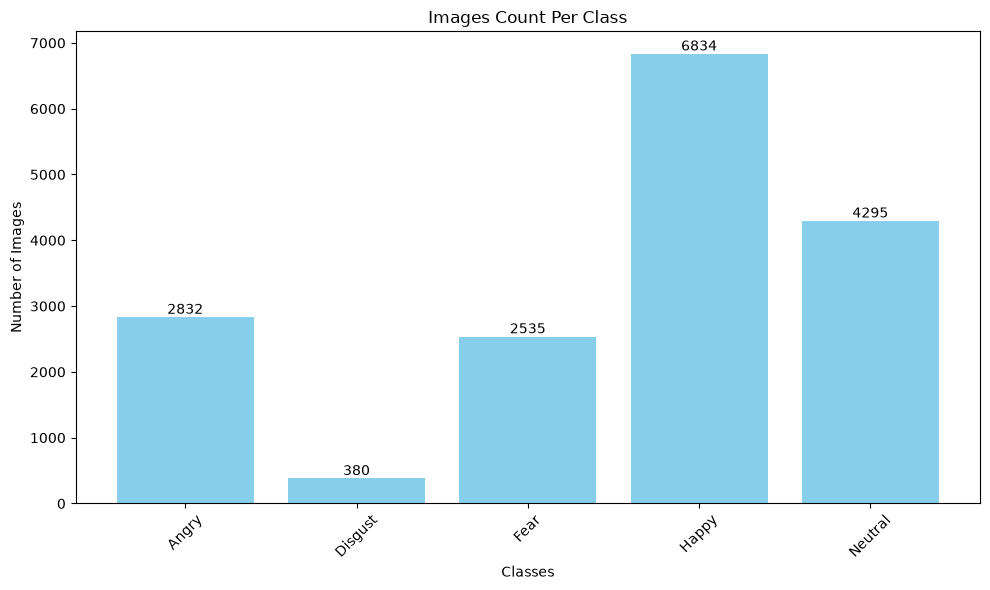

In [8]:
import matplotlib.pyplot as plt

classes = list(image_counts.keys())
classes_count = list(image_counts.values())

plt.figure(figsize=(10, 6))

# تعديل اسم اللون إلى skyblue
bars = plt.bar(classes, classes_count, color='skyblue')

for i in range(len(classes)):
    plt.text(i, classes_count[i] + 0.5, str(classes_count[i]), ha='center', va='bottom')

plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Images Count Per Class")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

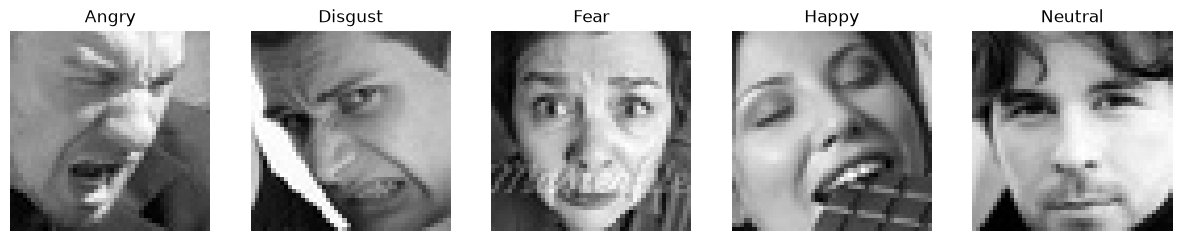

In [9]:
# Python Imaging Library
# pip install Pillow 
from PIL import Image

# إنشاء شكل من صف و خمسة أعمدة
fig, axs = plt.subplots(1, len(classes), figsize=(15, 3))
# الدوران على المجلدات المسماة بالأصناف
for i, class_name in enumerate(classes):
    # قائمة ملفات المجلد
    class_images = os.listdir(os.path.join(images_dir, class_name))
    # مسار أول صورة من المجلد
    img_path = os.path.join(images_dir, class_name, class_images[0])
    # تحميل الصورة
    img = Image.open(img_path)
    # إظهار الصورة
    axs[i].imshow(img, cmap='gray')
    # عنوان الصورة
    axs[i].set_title(class_name)
    # حذف المحاور
    axs[i].axis('off')

plt.show()

In [10]:
# تحديد قياس الصور
Image_Height = 48
Image_Width = 48
# قياس الصور المناسب
target_size = (Image_Height, Image_Width)

In [11]:
# قائمة بأسماء ملفات الصور
image_files = []
# قائمة بتسمية الصنف الموافق
labels = []


# تعبئة القوائم
for root, dirs, files in os.walk(images_dir):
    for file in files:
        # اختبار الصور من اللاحقة
        if file.endswith(('.jpg', '.jpeg', '.png')):
            # الإضافة لقائمة أسماء الملفات
            image_files.append(os.path.join(root, file))
            # إضافة اسم الصنف
            labels.append(os.path.basename(root))

In [12]:
print(image_files[0])
print(labels[0])

images/Angry/Training_10017485.jpg
Angry


In [13]:
# التقسيم لتدريب واختبار
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(image_files, labels, test_size=0.2, random_state=42)

In [14]:
# تحميل صورة والمعالجة الأولية لها
def load_and_preprocess_image(image_path, target_size):
    # تحميل صورة
    img = Image.open(image_path)
    # التحويل لصور ملونة
    img = img.convert('RGB') if img.mode != 'RGB' else img
    # ضبط حجم الصورة
    img = img.resize(target_size)
    # التحويل لمصفوفة نمباي وتقييس الصورة
    img = np.array(img) / 255.0
    return img

In [15]:
# تطبيق الدالة السابقة
X_train_processed = np.array([load_and_preprocess_image(image_path, target_size) for image_path in X_train])
X_test_processed = np.array([load_and_preprocess_image(image_path, target_size) for image_path in X_test])


In [16]:
# مكتبة مرمز الأصناف
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
# ترميز خرج التدريب
y_train_encoded = label_encoder.fit_transform(y_train)
# ترميز خرج الاختبار
y_test_encoded = label_encoder.transform(y_test)
y_test_encoded

array([3, 3, 3, ..., 3, 0, 3], shape=(3376,))

In [17]:
# قائمة أسماء الأصناف مفهرسة وفق الترميز
classes_labels=[]
for i in range(count_classes):
    class_label=label_encoder.inverse_transform([i])
    classes_labels.append(class_label[0])
classes_labels

[np.str_('Angry'),
 np.str_('Disgust'),
 np.str_('Fear'),
 np.str_('Happy'),
 np.str_('Neutral')]

In [18]:
# مكتبة تحويل الترميز إلى فئوي
from keras.utils import to_categorical
y_train_categorical = to_categorical(y_train_encoded)
y_test_categorical = to_categorical(y_test_encoded)
y_test_categorical

I0000 00:00:1787304776.049169   66927 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


array([[0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       ...,
       [0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.]], shape=(3376, 5))

In [19]:
# تثبيت العشوائية لتوليد نفس النتائج كل مرة
import random
import numpy as np
import tensorflow as tf
# يُمكن استخدام أي رقم لبذرة العشوائيه
seed_value = 42 
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)

In [20]:
from keras.applications import VGG16

# تحميل النموذج المدرب
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(Image_Height, Image_Width, 3))

# تجميد كافة طبقات النموذج المدرب
for layer in base_model.layers:
    layer.trainable = False

print("Layers : ", len(base_model.layers))
base_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
Layers :  19


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [21]:
from keras.models import Sequential
from keras.layers import Input, Flatten, Dense, Dropout
from keras.optimizers import Adam

# نموذج تسلسلي
model = Sequential()
# طبقة الدخل
model.add(Input(shape=(Image_Height, Image_Width, 3)))  
# إضافة النموذج المدرب
model.add(base_model)  
# إضافة طبقة تسطيح
model.add(Flatten()) 
# طبقة تسريب
model.add(Dropout(0.2))  
# طبقة كثيفة
model.add(Dense(128, activation='relu'))  
# طبقة تسريب
model.add(Dropout(0.2))  
# طبقة كثيفة
model.add(Dense(64, activation='relu'))  
# طبقة الخرج
model.add(Dense(count_classes, activation='softmax'))  

# تهيئة النموذج
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# طباعة ملخص النموذج
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,788,933 (56.42 MB)

 Trainable params: 74,245 (290.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [22]:
# تدريب النموذج
epochs = 16
history = model.fit(
    X_train_processed, 
    y_train_categorical,
    epochs=epochs,
    validation_data=(X_test_processed, y_test_categorical)
)

Epoch 1/16
422/422 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.4279 - loss: 1.3337 - val_accuracy: 0.4828 - val_loss: 1.2585
Epoch 2/16
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4673 - loss: 1.2700 - val_accuracy: 0.5000 - val_loss: 1.2340
Epoch 3/16
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4779 - loss: 1.2486 - val_accuracy: 0.4861 - val_loss: 1.2246
Epoch 4/16
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.4933 - loss: 1.2255 - val_accuracy: 0.4935 - val_loss: 1.2106
Epoch 5/16
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4990 - loss: 1.2088 - val_accuracy: 0.5142 - val_loss: 1.1985
Epoch 6/16
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5088 - loss: 1.1949 - val_accuracy: 0.5101 - val_loss: 1.1904
Epoch 7/16
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5150 - loss: 1.1837 - val_accuracy: 0.5163 - val_loss: 1.1852
Epoch 8/16
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5245 - loss: 1.1710 - val_accuracy:

In [23]:
# تقييم النموذج

score = model.evaluate(X_test_processed, y_test_categorical)
print('Test accuracy:', round(score[1]*100, 2))

106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5278 - loss: 1.1712
Test accuracy: 52.78


In [24]:
# تجميد كافة طبقات النموذج المدرب
for layer in base_model.layers:
    layer.trainable = False
# صقل النموذج المدرب بفك تجميد بعض الطبقات الأخيرة منه
for layer in base_model.layers[-4:]:
    layer.trainable = True

In [25]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [26]:
# نموذج تسلسلي
model = Sequential()
# طبقة الدخل
model.add(Input(shape=(Image_Height, Image_Width, 3)))  
# إضافة النموذج المدرب
model.add(base_model)  
# إضافة طبقة تسطيح
model.add(Flatten()) 
# طبقة تسريب
model.add(Dropout(0.2))  
# طبقة كثيفة
model.add(Dense(128, activation='relu'))  
# طبقة تسريب
model.add(Dropout(0.2))  
# طبقة كثيفة
model.add(Dense(64, activation='relu'))  
# طبقة الخرج
model.add(Dense(count_classes, activation='softmax'))  

# تهيئة النموذج
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# طباعة ملخص النموذج
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,788,933 (56.42 MB)

 Trainable params: 7,153,669 (27.29 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [27]:
# تدريب النموذج
history = model.fit(
    X_train_processed, 
    y_train_categorical,
    epochs=epochs,
    validation_data=(X_test_processed, y_test_categorical)
)

Epoch 1/16
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.4592 - loss: 1.2857 - val_accuracy: 0.5616 - val_loss: 1.1546
Epoch 2/16
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5989 - loss: 1.0488 - val_accuracy: 0.6191 - val_loss: 1.0117
Epoch 3/16
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6418 - loss: 0.9456 - val_accuracy: 0.6360 - val_loss: 0.9561
Epoch 4/16
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6669 - loss: 0.8852 - val_accuracy: 0.6460 - val_loss: 0.9343
Epoch 5/16
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6841 - loss: 0.8438 - val_accuracy: 0.6392 - val_loss: 0.9927
Epoch 6/16
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7046 - loss: 0.7867 - val_accuracy: 0.6425 - val_loss: 0.9647
Epoch 7/16
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7198 - loss: 0.7465 - val_accuracy: 0.6440 - val_loss: 0.9999
Epoch 8/16
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7377 - loss: 0.7036 - val_accuracy

In [28]:
# تقييم النموذج

score = model.evaluate(X_test_processed, y_test_categorical)
print('Test accuracy:', round(score[1]*100, 2))

106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6262 - loss: 1.3961
Test accuracy: 62.62


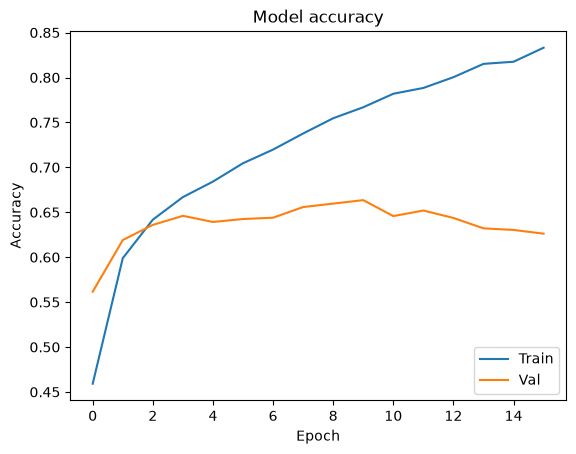

In [29]:
# مشاهدة دقة التدريب والتقييم مع عدد الدورات

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

In [30]:
# التنبؤ على بيانات التقييم
y_pred = model.predict(X_test_processed)
y_pred

106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


array([[5.4278772e-02, 8.5014943e-03, 7.2345451e-02, 7.4068940e-01,
        1.2418490e-01],
       [8.6420318e-03, 3.5495352e-05, 1.0292370e-02, 9.7698802e-01,
        4.0419730e-03],
       [1.1025072e-01, 2.7583968e-02, 1.0213822e-01, 3.7797254e-01,
        3.8205463e-01],
       ...,
       [3.6420763e-01, 6.1232405e-04, 6.0779917e-01, 2.4388829e-02,
        2.9921189e-03],
       [9.4524288e-01, 2.3369952e-05, 5.4008089e-02, 5.4490002e-04,
        1.8072846e-04],
       [2.4221782e-01, 6.0776681e-02, 1.5010247e-01, 2.0761167e-01,
        3.3929139e-01]], shape=(3376, 5), dtype=float32)

In [31]:
# التحويل من احتمالات الأصناف إلى ترميزها 
y_pred = np.argmax(y_pred, axis=1)   
y_pred

array([3, 3, 4, ..., 2, 0, 4], shape=(3376,))

In [32]:
# إيجاد تسميات الأصناف الموافقة للترميزات
pred_class_labels = []
for c in y_pred:
    pred_class_labels.append(label_encoder.inverse_transform([c])[0])

pred_class_labels

[np.str_('Happy'),
 np.str_('Happy'),
 np.str_('Neutral'),
 np.str_('Happy'),
 np.str_('Neutral'),
 np.str_('Happy'),
 np.str_('Happy'),
 np.str_('Happy'),
 np.str_('Happy'),
 np.str_('Happy'),
 np.str_('Neutral'),
 np.str_('Fear'),
 np.str_('Angry'),
 np.str_('Fear'),
 np.str_('Happy'),
 np.str_('Happy'),
 np.str_('Disgust'),
 np.str_('Happy'),
 np.str_('Angry'),
 np.str_('Happy'),
 np.str_('Happy'),
 np.str_('Neutral'),
 np.str_('Neutral'),
 np.str_('Neutral'),
 np.str_('Neutral'),
 np.str_('Fear'),
 np.str_('Happy'),
 np.str_('Neutral'),
 np.str_('Angry'),
 np.str_('Angry'),
 np.str_('Happy'),
 np.str_('Neutral'),
 np.str_('Disgust'),
 np.str_('Neutral'),
 np.str_('Fear'),
 np.str_('Happy'),
 np.str_('Neutral'),
 np.str_('Fear'),
 np.str_('Fear'),
 np.str_('Happy'),
 np.str_('Neutral'),
 np.str_('Neutral'),
 np.str_('Neutral'),
 np.str_('Neutral'),
 np.str_('Neutral'),
 np.str_('Fear'),
 np.str_('Fear'),
 np.str_('Happy'),
 np.str_('Neutral'),
 np.str_('Angry'),
 np.str_('Happy'),
 

In [33]:
# مصفوفة الارتباك
from sklearn.metrics import confusion_matrix 
# حساب مصفوفة الارتباك
cm = confusion_matrix(y_test, pred_class_labels)
cm

array([[263,  28,  64,  33, 160],
       [ 20,  39,   5,   3,  11],
       [ 98,  10, 237,  32, 126],
       [ 93,   8,  73, 946, 276],
       [ 83,   8,  62,  69, 629]])

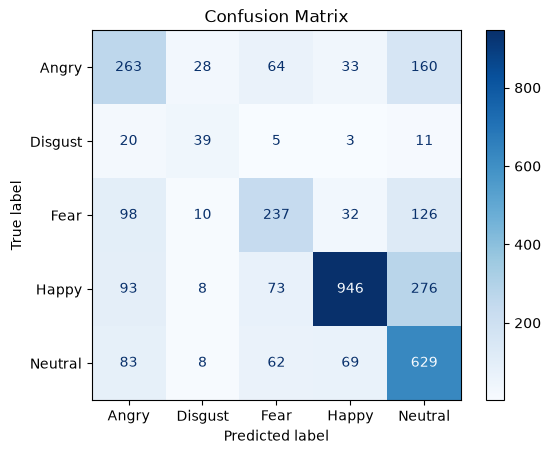

In [34]:
from sklearn.metrics import  ConfusionMatrixDisplay
# رسم مصفوفة الارتباك
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes_labels)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix')
plt.show()